In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import warnings

C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data = pd.read_csv('../datas/crx.data', sep=',', header=None, na_values='?')
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 处理特征
for col in X.columns:
    if X[col].dtype == 'object':
        # 分类特征
        X[col] = X[col].fillna(X[col].mode()[0])
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        # 数值特征
        X[col] = X[col].fillna(X[col].median())

# 处理目标
y_encoder = LabelEncoder()
y_encoded = y_encoder.fit_transform(y.fillna(y.mode()[0]))

print("处理后的数据:")
print(X.head())

处理后的数据:
   0      1      2   3   4   5   6     7   8   9   10  11  12     13   14
0   1  30.83  0.000   1   0  12   7  1.25   1   1   1   0   0  202.0    0
1   0  58.67  4.460   1   0  10   3  3.04   1   1   6   0   0   43.0  560
2   0  24.50  0.500   1   0  10   3  1.50   1   0   0   0   0  280.0  824
3   1  27.83  1.540   1   0  12   7  3.75   1   1   5   1   0  100.0    3
4   1  20.17  5.625   1   0  12   7  1.71   1   0   0   0   2  120.0    0


In [3]:
# 基于惩罚项的特征选择法
estimator = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')
# 系数绝对值大于0.01的特征被选中
sfm = SelectFromModel(estimator, threshold=0.01)
sfm.fit(X, y_encoded)
X_scaled = sfm.transform(X)
print("特征选择后的数据形状:", X_scaled.shape)
print("系数:", sfm.estimator_.coef_)

特征选择后的数据形状: (690, 8)
系数: [[ 0.00000000e+00  2.82044541e-02  2.30601635e-02  8.45751182e-01
   0.00000000e+00 -1.94794720e-02  2.76839657e-02 -1.07800349e-01
  -2.62517324e+00  0.00000000e+00 -1.65708413e-01  0.00000000e+00
   0.00000000e+00  2.05092924e-03 -4.06948874e-04]]


In [4]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=10)
print("训练集形状:", x_train.shape)
print("测试集形状:", x_test.shape)

训练集形状: (552, 8)
测试集形状: (138, 8)


In [5]:
# KNN
KNN = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='kd_tree')
KNN.fit(x_train, y_train)
train_predict = KNN.predict(x_train)
test_predict = KNN.predict(x_test)
acc_train = accuracy_score(y_train, train_predict)
acc_test = accuracy_score(y_test, test_predict)
print("训练集准确率: ", acc_train)
print("测试集准确率: ", acc_test)

训练集准确率:  0.8278985507246377
测试集准确率:  0.6666666666666666


In [6]:
print(classification_report(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.73      0.51      0.60        68
           1       0.63      0.81      0.71        70

    accuracy                           0.67       138
   macro avg       0.68      0.66      0.66       138
weighted avg       0.68      0.67      0.66       138



In [7]:
# 逻辑回归
logis = LogisticRegression()
logis.fit(x_train, y_train)
logis_train_pred = logis.predict(x_train)
logis_test_pred = logis.predict(x_test)
logis_train = accuracy_score(y_train, logis_train_pred)
logis_test = accuracy_score(y_test, logis_test_pred)
print("训练集准确率: ", logis_train)
print("测试集准确率: ", logis_test)

训练集准确率:  0.8496376811594203
测试集准确率:  0.9057971014492754


In [8]:
print(classification_report(y_test, logis_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        68
           1       0.94      0.87      0.90        70

    accuracy                           0.91       138
   macro avg       0.91      0.91      0.91       138
weighted avg       0.91      0.91      0.91       138



In [9]:
# 不使用特征选择
x_train2, x_test2, y_train2, y_test2 = train_test_split(X, y_encoded, test_size=0.2, random_state=10)
print("训练集形状:", x_train2.shape)
print("测试集形状:", x_test2.shape)

训练集形状: (552, 15)
测试集形状: (138, 15)


In [10]:
# KNN
KNN2 = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='kd_tree')
KNN2.fit(x_train2, y_train2)
train_predict2 = KNN2.predict(x_train2)
test_predict2 = KNN2.predict(x_test2)
acc_train2 = accuracy_score(y_train2, train_predict2)
acc_test2 = accuracy_score(y_test2, test_predict2)
print("不使用特征选择")
print("训练集准确率: ", acc_train2)
print("测试集准确率: ", acc_test2)

不使用特征选择
训练集准确率:  0.7844202898550725
测试集准确率:  0.6594202898550725


In [11]:
print(classification_report(y_test2, test_predict2))

              precision    recall  f1-score   support

           0       0.71      0.53      0.61        68
           1       0.63      0.79      0.70        70

    accuracy                           0.66       138
   macro avg       0.67      0.66      0.65       138
weighted avg       0.67      0.66      0.65       138



In [12]:
# 逻辑回归
logis2 = LogisticRegression()
logis2.fit(x_train2, y_train2)
logis_train_pred2 = logis2.predict(x_train2)
logis_test_pred2 = logis2.predict(x_test2)
logis_train2 = accuracy_score(y_train2, logis_train_pred2)
logis_test2 = accuracy_score(y_test2, logis_test_pred2)
print("不使用特征选择")
print("训练集准确率: ", logis_train2)
print("测试集准确率: ", logis_test2)

不使用特征选择
训练集准确率:  0.842391304347826
测试集准确率:  0.8913043478260869


In [13]:
print(classification_report(y_test2, logis_test_pred2))

              precision    recall  f1-score   support

           0       0.92      0.85      0.89        68
           1       0.87      0.93      0.90        70

    accuracy                           0.89       138
   macro avg       0.89      0.89      0.89       138
weighted avg       0.89      0.89      0.89       138



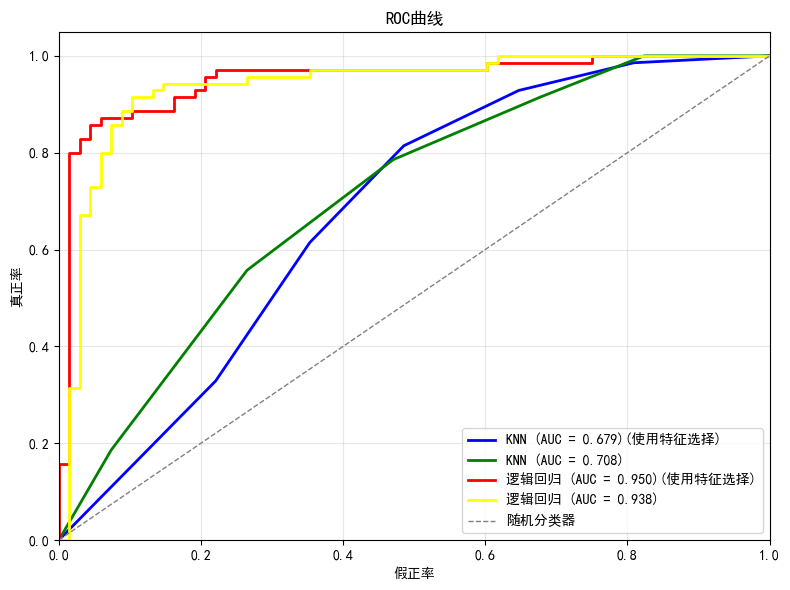

In [14]:
# 绘制ROC曲线
plt.figure(figsize=(8, 6))

# 计算ROC曲线和AUC
knn_proba = KNN.predict_proba(x_test)[:, 1]
lr_proba = logis.predict_proba(x_test)[:, 1]
knn_proba2 = KNN2.predict_proba(x_test2)[:, 1]
lr_proba2 = logis2.predict_proba(x_test2)[:, 1]

knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_proba)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
knn_fpr2, knn_tpr2, _ = roc_curve(y_test2, knn_proba2)
lr_fpr2, lr_tpr2, _ = roc_curve(y_test2, lr_proba2)

knn_auc = auc(knn_fpr, knn_tpr)
lr_auc = auc(lr_fpr, lr_tpr)
knn_auc2 = auc(knn_fpr2, knn_tpr2)
lr_auc2 = auc(lr_fpr2, lr_tpr2)

plt.plot(knn_fpr, knn_tpr, color='blue', lw=2, label=f'KNN (AUC = {knn_auc:.3f})(使用特征选择)')
plt.plot(knn_fpr2, knn_tpr2, color='green', lw=2, label=f'KNN (AUC = {knn_auc2:.3f})')
plt.plot(lr_fpr, lr_tpr, color='red', lw=2, label=f'逻辑回归 (AUC = {lr_auc:.3f})(使用特征选择)')
plt.plot(lr_fpr2, lr_tpr2, color='yellow', lw=2, label=f'逻辑回归 (AUC = {lr_auc2:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='随机分类器')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()